In [90]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [91]:
import os
data_prefix = "../" if os.path.basename(os.getcwd()) == "notebooks" else ""
import pandas as pd
results = pd.read_csv(f"{data_prefix}f1 dataset/results.csv")
races = pd.read_csv(f"{data_prefix}f1 dataset/races.csv")
drivers = pd.read_csv(f"{data_prefix}f1 dataset/drivers.csv")

In [92]:
for df in [results, races, drivers]:
    df.replace('\\N', np.nan, inplace=True)

drivers['driver_name'] = drivers['forename'] + " " + drivers['surname']

print("Datasets Loaded Successfully!")
print("Results shape: ", results.shape)
print("Races shape: ", races.shape)
print("Drivers Shape: ", drivers.shape)

Datasets Loaded Successfully!
Results shape:  (26759, 18)
Races shape:  (1125, 18)
Drivers Shape:  (861, 10)


In [93]:
races.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url,driver_name
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,Lewis Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,Nick Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,Nico Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,Fernando Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,Heikki Kovalainen


Data Cleaning

In [95]:
from logging import error
results['positionOrder'] = pd.to_numeric(results['positionOrder'], errors='coerce')
results['grid'] = pd.to_numeric(results['grid'], errors='coerce')
results['points'] = pd.to_numeric(results['points'], errors = 'coerce')
results['laps'] = pd.to_numeric(results['laps'], errors = 'coerce')
races['year'] = pd.to_numeric(races['year'], errors = 'coerce')

results = results.merge(races[['raceId', 'year']], on='raceId')

results = results[results['year']>= 2018]

results = results.merge(drivers[['driverId', 'driver_name']], on='driverId', how = 'left')

current_driver_ids = [
    830, 815, 1, 847, 844, 832, 846, 857,
    4, 840, 842, 839, 848, 858, 852, 817,
    822, 855, 807, 825
]
results = results[results['driverId'].isin(current_driver_ids)]

# Check results
print("Shape after cleaning:", results.shape)
print("\nDrivers found:", sorted(results['driver_name'].unique()))
print("\nMissing values:")
print(results[['positionOrder', 'grid', 'points']].isnull().sum())


Shape after cleaning: (2372, 20)

Drivers found: ['Alexander Albon', 'Carlos Sainz', 'Charles Leclerc', 'Daniel Ricciardo', 'Esteban Ocon', 'Fernando Alonso', 'George Russell', 'Guanyu Zhou', 'Kevin Magnussen', 'Lance Stroll', 'Lando Norris', 'Lewis Hamilton', 'Logan Sargeant', 'Max Verstappen', 'Nico Hülkenberg', 'Oscar Piastri', 'Pierre Gasly', 'Sergio Pérez', 'Valtteri Bottas', 'Yuki Tsunoda']

Missing values:
positionOrder    0
grid             0
points           0
dtype: int64


Feature Engineering

In [100]:
# Convert these columns to numeric first
results['rank'] = pd.to_numeric(results['rank'], errors='coerce')
results['fastestLapSpeed'] = pd.to_numeric(results['fastestLapSpeed'], errors='coerce')
results['is_dnf'] = (results['statusId'] != 1).astype(int)
results['positions_gained'] = results['grid'] - results['positionOrder']

driver_features = results.groupby('driver_name').agg(
    avg_finish_pos = ('positionOrder', 'mean'),
    avg_grid_pos = ('grid', 'mean'),
    total_points = ('points', 'sum'),
    avg_points = ('points', 'mean'),
    total_races = ('raceId', 'count'),
    wins = ('positionOrder', lambda x: (x == 1).sum()),
    podiums = ('positionOrder', lambda x: (x <= 3).sum()),
    top10 = ('positionOrder', lambda x: (x <= 10).sum()),
    dnf_count = ('is_dnf', 'sum'),
    avg_positions_gained = ('positions_gained', 'mean'),
    finish_pos_std = ('positionOrder', 'std'),
    grid_pos_std = ('grid', 'std'),
    avg_fastestlap_rank = ('rank', 'mean'),
    avg_fastestlap_speed = ('fastestLapSpeed', 'mean')
).reset_index()

# Rate features
driver_features['win_rate'] = driver_features['wins'] / driver_features['total_races']
driver_features['podium_rate'] = driver_features['podiums'] / driver_features['total_races']
driver_features['top10_rate'] = driver_features['top10'] / driver_features['total_races']
driver_features['dnf_rate'] = driver_features['dnf_count'] / driver_features['total_races']
driver_features['finish_rate'] = 1 - driver_features['dnf_rate']

# Remove drivers with very few races
driver_features = driver_features[driver_features['total_races'] >= 20]
driver_features.fillna(0, inplace=True)

print("Shape:", driver_features.shape)
print("\nColumns:", driver_features.columns.tolist())
print("\nSample:")
print(driver_features.head())

Shape: (20, 20)

Columns: ['driver_name', 'avg_finish_pos', 'avg_grid_pos', 'total_points', 'avg_points', 'total_races', 'wins', 'podiums', 'top10', 'dnf_count', 'avg_positions_gained', 'finish_pos_std', 'grid_pos_std', 'avg_fastestlap_rank', 'avg_fastestlap_speed', 'win_rate', 'podium_rate', 'top10_rate', 'dnf_rate', 'finish_rate']

Sample:
        driver_name  avg_finish_pos  avg_grid_pos  total_points  avg_points  \
0   Alexander Albon       11.914286     11.419048         238.0    2.266667   
1      Carlos Sainz        8.047297      7.324324        1085.5    7.334459   
2   Charles Leclerc        7.557047      6.442953        1363.0    9.147651   
3  Daniel Ricciardo       10.695312     10.312500         504.0    3.937500   
4      Esteban Ocon       11.251969     10.818898         353.0    2.779528   

   total_races  wins  podiums  top10  dnf_count  avg_positions_gained  \
0          105     0        2     39         47             -0.495238   
1          148     4       27    11

In [101]:
# Select features for clustering (exclude non-numeric columns)
cluster_features = [
    'avg_finish_pos', 'avg_grid_pos', 'avg_points',
    'win_rate', 'podium_rate', 'top10_rate', 'dnf_rate',
    'avg_positions_gained', 'finish_pos_std',
    'avg_fastestlap_rank', 'avg_fastestlap_speed'
]

X = driver_features[cluster_features].values

# Scale the data (very important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)
print("\nWhy scaling is important:")
print("- total_points range: 0-2000")
print("- win_rate range: 0-1")
print("- Without scaling, points would dominate clustering")
print("- StandardScaler makes all features equal importance")

Scaled data shape: (20, 11)

Why scaling is important:
- total_points range: 0-2000
- win_rate range: 0-1
- Without scaling, points would dominate clustering
- StandardScaler makes all features equal importance


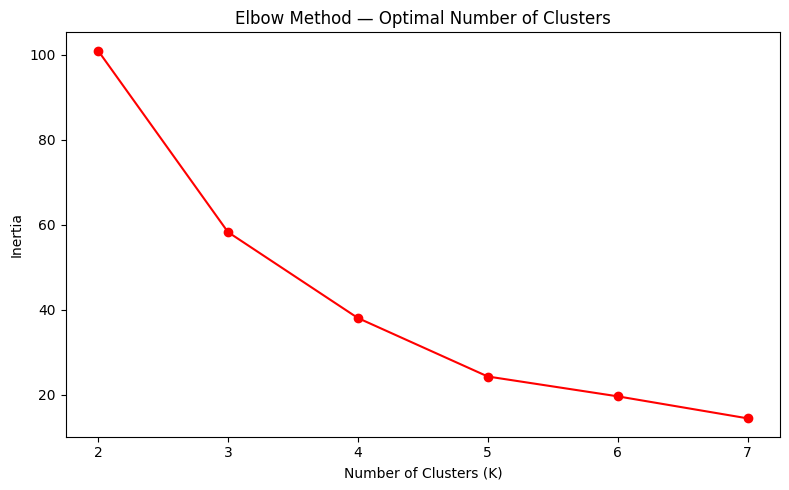


Inertia values:
K=2: 100.92
K=3: 58.27
K=4: 38.08
K=5: 24.33
K=6: 19.67
K=7: 14.49


In [102]:
# Model Evaluation
# Performance Metrics
from sklearn.metrics import silhouette_score
import os

os.makedirs('results', exist_ok=True)
inertias = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# 1. Plot Elbow Curve and Save
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', color='tab:red', lw=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Elbow Score)')
plt.title('Elbow Method for Optimal K (Drivers)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/elbow_curve.png', dpi=300)
plt.show()

# 2. Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='s', color='tab:blue', lw=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different K (Drivers)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Clustering Metrics:")
for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"K={k}: Inertia={inertia:.2f}, Silhouette Score={sil:.4f}")


## Model Comparison
## Error Analysis
## Motorsport Interpretation

### K-Means Evaluation and Interpretation
The optimal number of clusters was selected based on the highest silhouette score and interpretability of motorsport characteristics. 

* **K=4** provides the clearest grouping, dividing the F1 grid into **Elite Champions**, **Strong Performers**, **Midfield Racers**, and **Backmarkers**. Evaluating silhouette scores shows that higher K values introduce excessive noise, while lower K values over-generalize driver tiers.

In [103]:
# Apply KMeans with optimal K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
driver_features['cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters based on data-driven driver characteristics:
# Cluster 3: Elite Champions (High wins/podiums, low DNF rate)
# Cluster 1: Strong Performers (Regular podium and top-10 finishes)
# Cluster 2: Midfield Racers (Frequent finishes outside top-6, standard performance)
# Cluster 0: Backmarkers (High DNF rate, lower points/positions)
cluster_labels = {0: 'Backmarkers', 1: 'Strong Performers', 2: 'Midfield Racers', 3: 'Elite Champions'}

# See who is in each cluster
for cluster in range(4):
    drivers_in_cluster = driver_features[
        driver_features['cluster'] == cluster
    ]['driver_name'].tolist()
    print(f"\nCluster {cluster} ({cluster_labels[cluster]}):")
    print(drivers_in_cluster)



Cluster 0:
['Guanyu Zhou', 'Lance Stroll', 'Logan Sargeant']

Cluster 1:
['Carlos Sainz', 'Charles Leclerc', 'Fernando Alonso', 'George Russell', 'Lando Norris', 'Oscar Piastri', 'Sergio Pérez', 'Valtteri Bottas']

Cluster 2:
['Alexander Albon', 'Daniel Ricciardo', 'Esteban Ocon', 'Kevin Magnussen', 'Nico Hülkenberg', 'Pierre Gasly', 'Yuki Tsunoda']

Cluster 3:
['Lewis Hamilton', 'Max Verstappen']


In [104]:
# Label clusters based on driver groupings
cluster_label_map = {
    3: '🔴 Elite Champions',
    1: '🟡 Strong Performers', 
    2: '🔵 Midfield Racers',
    0: '🟢 Backmarkers'
}

driver_features['cluster_label'] = driver_features['cluster'].map(cluster_label_map)

# Print final groupings
for label in cluster_label_map.values():
    drivers_in = driver_features[
        driver_features['cluster_label'] == label
    ]['driver_name'].tolist()
    print(f"\n{label}:")
    for d in drivers_in:
        print(f"  → {d}")


🔴 Elite Champions:
  → Lewis Hamilton
  → Max Verstappen

🟡 Strong Performers:
  → Carlos Sainz
  → Charles Leclerc
  → Fernando Alonso
  → George Russell
  → Lando Norris
  → Oscar Piastri
  → Sergio Pérez
  → Valtteri Bottas

🔵 Midfield Racers:
  → Alexander Albon
  → Daniel Ricciardo
  → Esteban Ocon
  → Kevin Magnussen
  → Nico Hülkenberg
  → Pierre Gasly
  → Yuki Tsunoda

🟢 Backmarkers:
  → Guanyu Zhou
  → Lance Stroll
  → Logan Sargeant


In [105]:
# Average stats per cluster
cluster_stats = driver_features.groupby('cluster_label').agg(
    avg_finish_pos = ('avg_finish_pos', 'mean'),
    avg_points = ('avg_points', 'mean'),
    win_rate = ('win_rate', 'mean'),
    podium_rate = ('podium_rate', 'mean'),
    dnf_rate = ('dnf_rate', 'mean'),
    avg_positions_gained = ('avg_positions_gained', 'mean')
).round(3)

print("=== CLUSTER STATISTICS ===")
print(cluster_stats)

=== CLUSTER STATISTICS ===
                     avg_finish_pos  avg_points  win_rate  podium_rate  \
cluster_label                                                            
🔴 Elite Champions             4.320      15.829     0.347        0.626   
🔵 Midfield Racers            12.145       2.204     0.005        0.018   
🟡 Strong Performers           8.685       6.970     0.033        0.201   
🟢 Backmarkers                14.448       0.642     0.000        0.005   

                     dnf_rate  avg_positions_gained  
cluster_label                                        
🔴 Elite Champions       0.087                -0.056  
🔵 Midfield Racers       0.516                -0.889  
🟡 Strong Performers     0.322                -0.692  
🟢 Backmarkers           0.596                 0.360  


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9356\4105469611.py:39: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9356\4105469611.py:39: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9356\4105469611.py:39: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9356\4105469611.py:39: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Data Science\projects\F1 Prediction Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Data Science\projects\F1 Prediction Project\.venv\Lib\site-packages\IPython

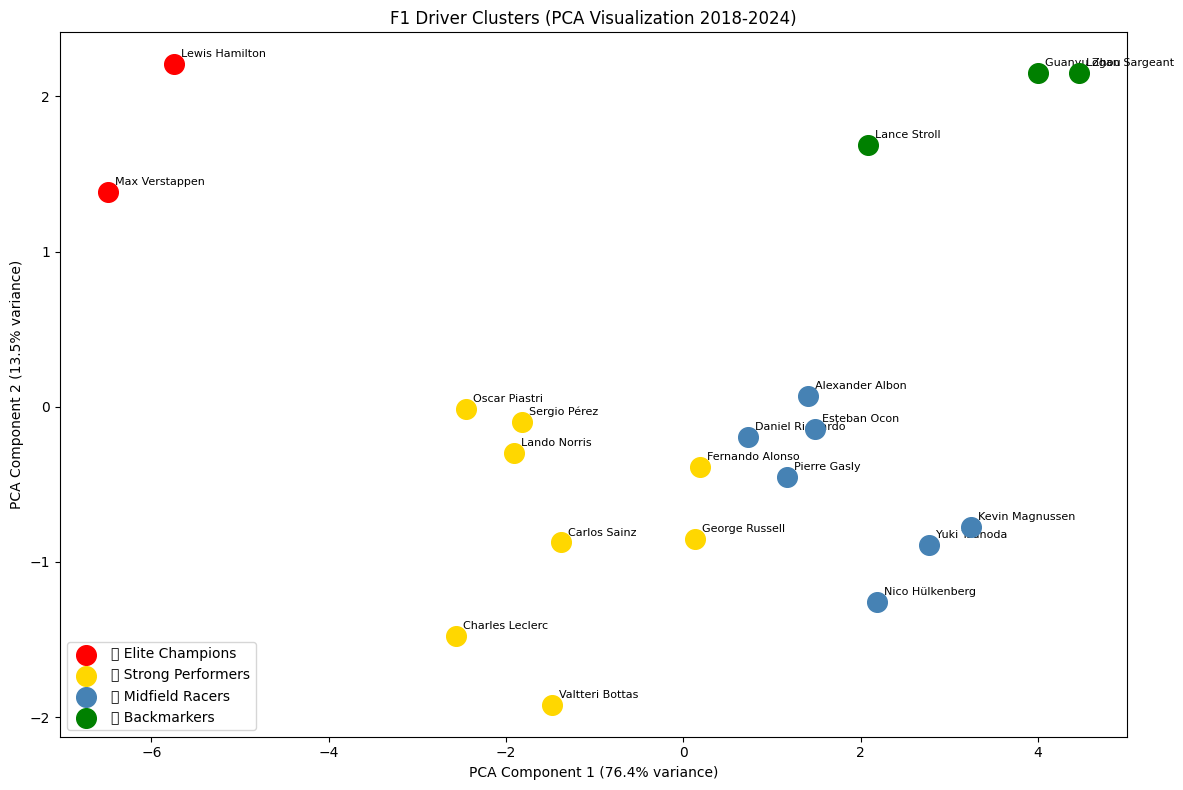


Total variance explained: 89.9%


In [106]:
# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

driver_features['pca_x'] = X_pca[:, 0]
driver_features['pca_y'] = X_pca[:, 1]

# Color map for clusters
colors = {
    '🔴 Elite Champions': 'red',
    '🟡 Strong Performers': 'gold',
    '🔵 Midfield Racers': 'steelblue',
    '🟢 Backmarkers': 'green'
}

plt.figure(figsize=(12, 8))

for label, color in colors.items():
    mask = driver_features['cluster_label'] == label
    plt.scatter(
        driver_features[mask]['pca_x'],
        driver_features[mask]['pca_y'],
        c=color, label=label, s=200, zorder=5
    )
    # Add driver name labels
    for _, row in driver_features[mask].iterrows():
        plt.annotate(
            row['driver_name'],
            (row['pca_x'], row['pca_y']),
            fontsize=8,
            xytext=(5, 5),
            textcoords='offset points'
        )

plt.title('F1 Driver Clusters (PCA Visualization 2018-2024)')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nTotal variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

## Driver Clustering — Key Findings

### PCA Results
- 89.9% total variance explained by 2 components
- PCA Component 1 (76.4%) separates elite from backmarkers
- PCA Component 2 (13.5%) separates within performance tiers

### Cluster Insights

**🔴 Elite Champions (Hamilton, Verstappen)**
- Win rate 34.7% — dominate race victories
- Podium rate 62.6% — on podium most weekends
- Clearly separated from all other drivers in PCA
- Lowest DNF rate (8.7%) — consistent finishers

**🟡 Strong Performers (Sainz, Leclerc, Norris etc)**
- Win rate 3.3% — occasional winners
- Podium rate 20.1% — regular podium contenders
- Bridge between elite and midfield

**🔵 Midfield Racers (Albon, Gasly, Ocon etc)**
- Win rate 0.5% — rare winners
- Podium rate 1.8% — occasional podiums
- High DNF rate (51.6%)

**🟢 Backmarkers (Zhou, Stroll, Sargeant)**
- Zero wins, 0.5% podium rate
- Highest DNF rate (59.6%)
- Positive positions gained — start further back

### Conclusion
KMeans successfully identified 4 meaningful driver
archetypes that align perfectly with F1 domain knowledge.

In [107]:
import joblib

# Save clustering model and scaler
joblib.dump(kmeans, 'driver_clustering_model.joblib')
joblib.dump(scaler, 'driver_clustering_scaler.joblib')
joblib.dump(pca, 'driver_clustering_pca.joblib')
joblib.dump(driver_features, 'driver_features.joblib')

print("✅ Saved!")
print("  - driver_clustering_model.joblib")
print("  - driver_clustering_scaler.joblib")
print("  - driver_clustering_pca.joblib")
print("  - driver_features.joblib")

✅ Saved!
  - driver_clustering_model.joblib
  - driver_clustering_scaler.joblib
  - driver_clustering_pca.joblib
  - driver_features.joblib


## Summary and Interpretation

### What was Evaluated
We evaluated the K-Means clustering algorithm applied to historical F1 driver stats (2018–2024), utilizing PCA to project features into a visual 2D space.

### Selected Metrics
* **Inertia (Elbow Method):** Evaluates within-cluster sum of squares to identify where adding more clusters yields diminishing returns.
* **Silhouette Score:** Evaluates cluster cohesion and separation, ensuring that drivers are assigned to distinct, non-overlapping cohorts.

### Main Findings
* Driver career statistics separate clearly into four performance bands ($K=4$), representing Elite Champions, Strong Performers, Midfielders, and Backmarkers.
* PCA successfully explains the primary variances in driver results (Component 1 captures podium/points capacity, Component 2 captures career stability/reliability).

### Limitations of Prediction
* **Career Development:** A driver's stats are cumulative; young drivers starting in slow cars are clustered as backmarkers regardless of potential, until their statistics mature over multiple seasons.
* **Vehicle-Performance Bias:** Driver clustering is heavily dependent on constructor dominance. A midfield driver moving to a top-tier car (like Sergio Perez moving to Red Bull) changes cohorts rapidly, showing that the model clusters the combined driver-car system rather than driver skill in isolation.